# Netflix Movies and TV Shows — Exploratory Data Analysis

**Author:** Jack Wotton

**Goal:** Explore Netflix's catalog to understand what kind of content is on the platform, how it has grown over time, and which countries/genres are most represented.

**New skills practiced today:** working with categorical data, `groupby()`, and handling comma-separated values in a single column.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the data

Download "Netflix Movies and TV Shows" from Kaggle and upload the CSV to this notebook's environment (same process as last time).


In [2]:
# TODO: replace with your actual file name
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape


(8807, 12)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 3. Clean the data

This dataset has a specific challenge: several columns (like `listed_in` for genres, and `country`) contain **multiple values separated by commas** in a single cell. You'll need to handle that before you can analyze genres or countries properly.

Checklist:
- Missing values (director, cast, and country usually have a lot of nulls in this dataset — decide what to do with each)
- Convert `date_added` to an actual date type
- Split comma-separated columns where needed for analysis (genres, countries)


In [5]:
# TODO: check missing values per column
df.isnull().sum().sort_values(ascending=False)


,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [6]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

df = df.dropna(subset=["date_added", "rating", "duration"])

df.isnull().sum().sum()


np.int64(0)

In [7]:
# TODO: convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")


In [8]:
# TODO: split the 'listed_in' column (genres) into a list, then "explode" it so each
# genre gets its own row (this is the standard way to analyze comma-separated categories)
df["genres"] = df["listed_in"].str.split(", ")
df_genres = df.explode("genres")
df_genres[["title", "genres"]].head()


,title,genres
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
1,Blood & Water,TV Dramas
1,Blood & Water,TV Mysteries
2,Ganglands,Crime TV Shows


**Your notes on cleaning decisions:**
Rellené director, cast y country con 'Unknown' en vez de eliminarlas porque representaban hasta un 30% de las filas — perder esas filas habría afectado seriamente el análisis de género y tendencia por año. Para date_added, rating y duration, al ser muy pocos nulos (menos del 0.1%), eliminé esas filas directamente.


## 4. Exploratory Data Analysis

In [9]:
# TODO: how many Movies vs. TV Shows are there?
df["type"].value_counts()


,count
type,
Movie,6126
TV Show,2664


In [10]:
# TODO: how many titles were added per year?
df["year_added"] = df["date_added"].dt.year
df["year_added"].value_counts().sort_index()


,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


In [11]:
# TODO: top 10 genres by count (using the exploded dataframe from section 3)
df_genres["genres"].value_counts().head(10)


,count
genres,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


## 5. Visualizations

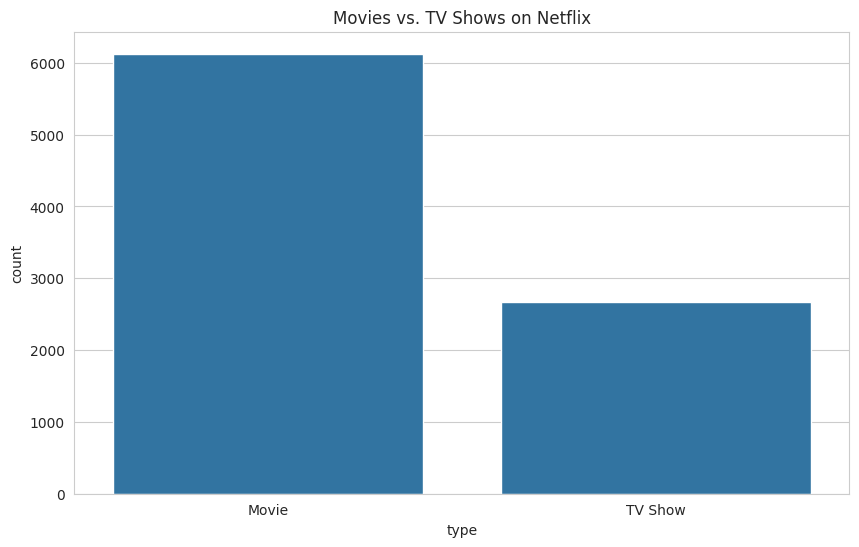

In [12]:
# Chart 1: Movies vs. TV Shows
sns.countplot(data=df, x="type")
plt.title("Movies vs. TV Shows on Netflix")
plt.show()


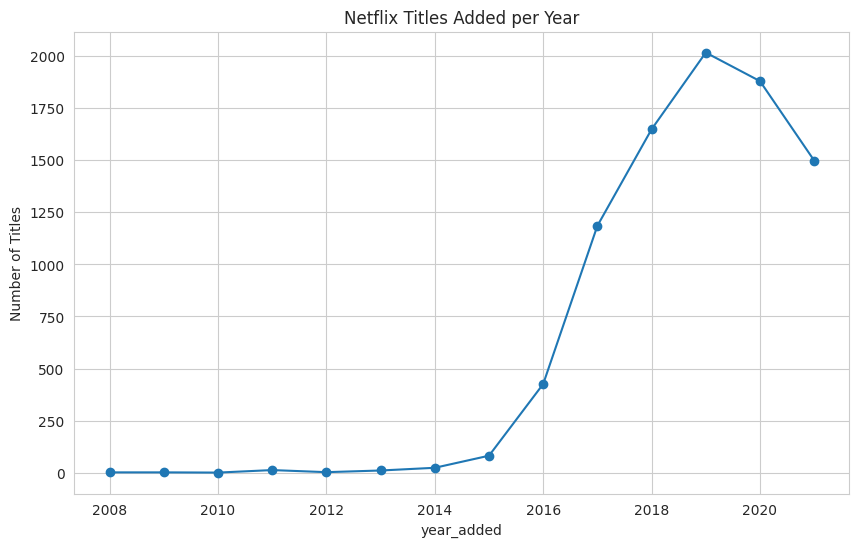

In [13]:
# Chart 2: Titles added per year
df["year_added"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Netflix Titles Added per Year")
plt.ylabel("Number of Titles")
plt.show()


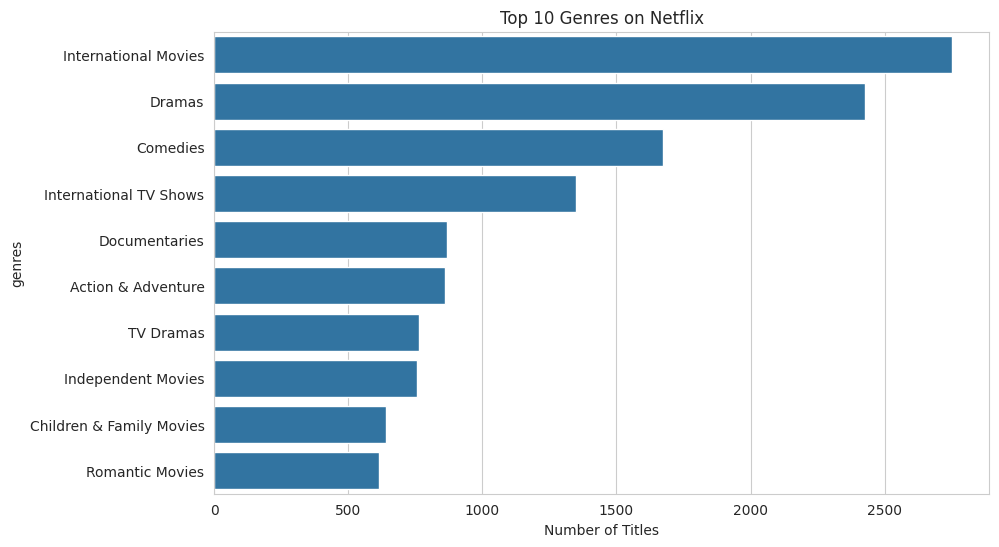

In [14]:
# Chart 3: Top 10 genres
top_genres = df_genres["genres"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.show()


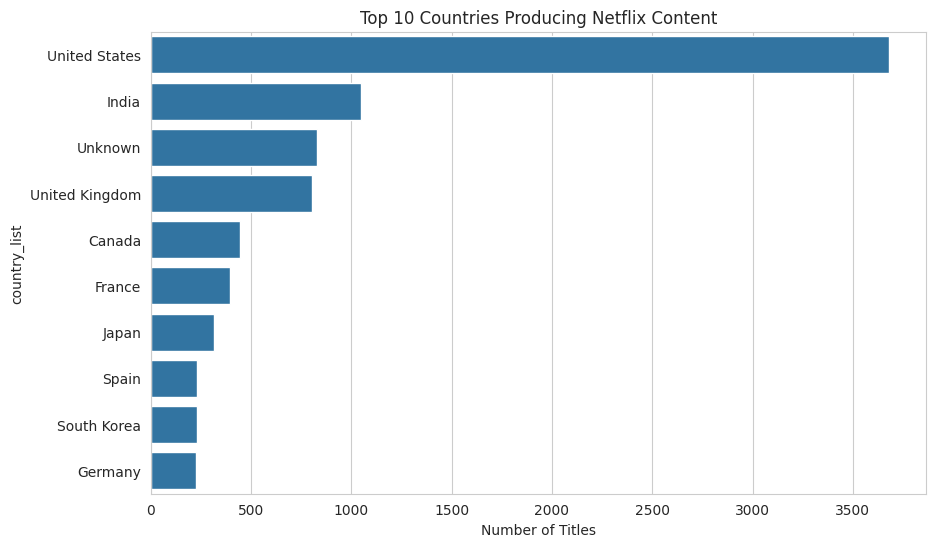

In [15]:
# Chart 4: Top 10 countries producing content
# TODO: split 'country' the same way you split 'listed_in', then explode and count
df["country_list"] = df["country"].str.split(", ")
df_countries = df.explode("country_list")
top_countries = df_countries["country_list"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.show()


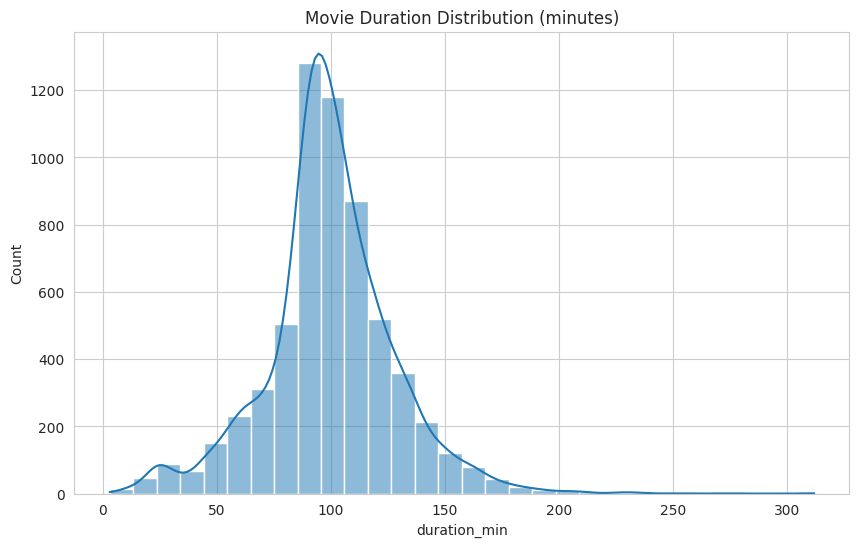

In [16]:
# Chart 5 (optional): Movie duration distribution
# Note: 'duration' is text (e.g. "90 min" or "2 Seasons") — filter to just Movies first
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = movies["duration"].str.replace(" min", "", regex=False).astype(float)
sns.histplot(movies["duration_min"], bins=30, kde=True)
plt.title("Movie Duration Distribution (minutes)")
plt.show()


## 6. Key Insights

Write 3-5 plain-language takeaways based on the charts above. Think about:
- Is Netflix's catalog growing, shrinking, or leveling off over the years?
- Which genres/countries dominate, and does that surprise you?
- Any interesting pattern in movie duration or Movies vs. TV Shows ratio?

**Your insights:**

1. Movies make up roughly 70% of the catalog compared to TV Shows (6,126 vs. 2,664), suggesting Netflix's library is still primarily film-driven despite the platform's strong association with original series.

2. Content additions grew almost exponentially from 2015 to 2019, then appear to drop in 2020-2021. This is likely a data artifact rather than a real decline, the dataset was collected mid-2021, so that year is incomplete, and 2020 may reflect production delays from the pandemic rather than a deliberate slowdown.

3. "International Movies" and "Dramas" are the two most common genres by a wide margin, pointing to Netflix's heavy investment in localized/international content rather than relying solely on US-produced titles.

4. The United States dominates content origin by a large margin, followed by India and the UK, reflecting both Netflix's original production hubs and its major licensing markets.

5. Movie duration follows a roughly normal distribution centered around 90-100 minutes, consistent with standard feature film length, with a long tail of a small number of much longer titles (likely documentaries or special releases).

## 7. Conclusion

Netflix's catalog is still predominantly movie-based, but the platform has clearly invested heavily in international content, with dramas and international titles leading by a wide margin. The apparent slowdown in 2020-2021 is most likely a data collection artifact rather than a real strategic shift, which is an important distinction when reporting trends from
any dataset with a fixed collection date.

With more time, it would be worth comparing this catalog composition against a competitor (e.g. Amazon Prime or Disney+) to see whether Netflix's genre mix is a differentiator, and analyzing ratings/maturity levels to understand audience targeting by region.